In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# define a function for our interval velocity 

In [2]:
def interval_velocity_func(initial_velocity, alpha, beta, omega, time): 
    return initial_velocity + alpha* np.sin(omega*time) + beta*time

In [3]:
init_velocity = 2000
a = 50
b = 20
f = 2
omega = 2 * np.pi * f

In [4]:
n_times = 200 
tmax = 2
time = np.linspace(0, tmax, n_times)

In [5]:
vint = interval_velocity_func(init_velocity, a, b, omega, time)

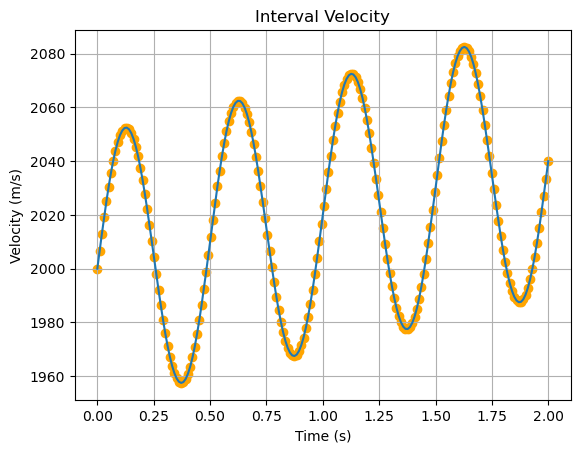

In [6]:
fig, ax = plt.subplots(1, 1) 

ax.plot(time, vint)
ax.scatter(time,vint,c='orange')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")
ax.set_title("Interval Velocity")
ax.grid()

fig.savefig("Q2A.png", dpi=300, bbox_inches="tight")

## RMS Velocity
Wolfram Alpha: integral(vint)^2 = integral(V0 + α sin(ω t) + β t)^2 dt = 
- +1/6 t (3 α^2 + 2 β^2 t^2 + 6 β t V0 + 6 V0^2) 
- -(α^2 sin(2 t ω))/(4 ω)
- +(2 α β sin(t ω))/ω^2
- -(2 α (β t + V0) cos(t ω))/ω
- Constant

vrms^2 = 1/t * integral(vint^2)

In [7]:
def rms_velocity(initial_velocity, alpha, beta, omega, time): 

    vrms = np.zeros(len(time))
    
    tinds_nonzero = time > 0 

    term1 = time[tinds_nonzero]/6*(3*alpha**2 + 2*beta**2 * time[tinds_nonzero]**2 + 6*beta*time[tinds_nonzero]*initial_velocity + 6*initial_velocity**2)
    term2 = alpha**2 * np.sin(2*time[tinds_nonzero]*omega) / (4*omega)
    term3 = 2*alpha*beta*np.sin(time[tinds_nonzero]*omega) / omega**2
    term4 = 2*alpha * (beta*time[tinds_nonzero] + initial_velocity) * np.cos(time[tinds_nonzero]*omega) / omega
    zeroterm = 2*alpha * initial_velocity / omega

    vrms2 = 1/time[tinds_nonzero]*(term1 - term2 + term3 - term4 + zeroterm)
    vrms[tinds_nonzero] = np.sqrt(vrms2)
    
    # treat the zero part 
    vrms[~tinds_nonzero] = initial_velocity 
    
    return vrms

In [8]:
vrms = rms_velocity(init_velocity, a, b, omega, time)
vrmsB0 = rms_velocity(init_velocity, a, 0, omega, time)

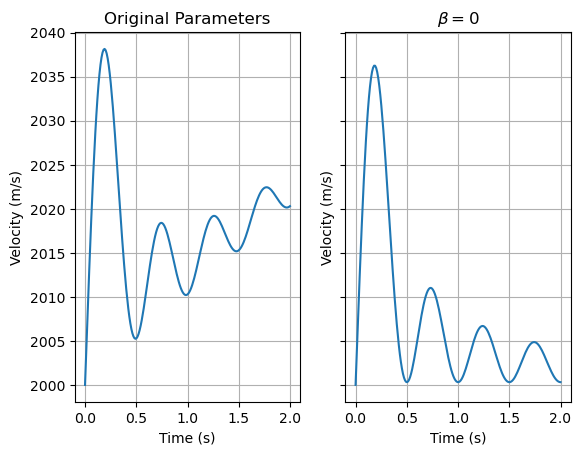

In [9]:
fig, ax = plt.subplots(1, 2, sharey= True) 

ax[0].plot(time, vrms)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Velocity (m/s)")
ax[0].set_title("Original Parameters")
ax[0].grid()

ax[1].plot(time, vrmsB0)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Velocity (m/s)")
ax[1].set_title(r"$\beta = 0$")
ax[1].grid()

fig.savefig("Q2C.png", dpi=300, bbox_inches="tight")

# estimate interval velocity from rms velocity 

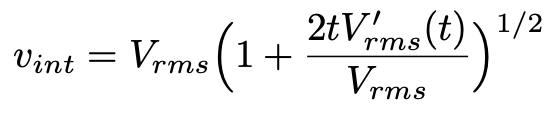

In [10]:
def compute_vint_from_vrms(time, vrms):
    #(class example) dt = np.diff(time)
    #(class example) vrms_grad_pos = np.diff(vrms)/dt
    #(class example) vrms_grad = np.r_[vrms_grad_pos[0]*2, vrms_grad_pos]
    vrms_grad = np.gradient(vrms, time, edge_order=2)
    vint_rec = vrms * np.sqrt(1 + 2*time*vrms_grad/vrms)
    return vint_rec

In [11]:
vint_rec = compute_vint_from_vrms(time, vrms)

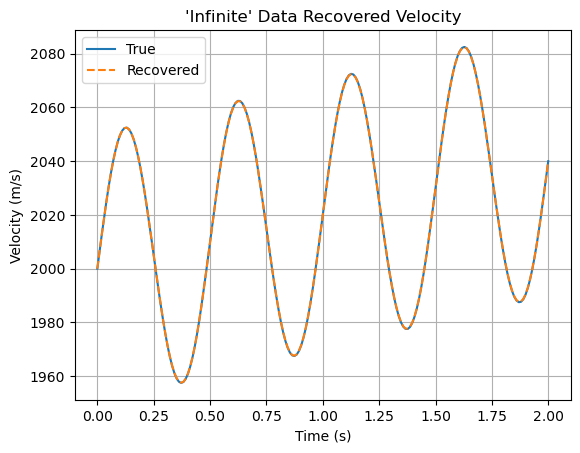

In [12]:
fig, ax = plt.subplots(1, 1)

ax.plot(time, vint, label="True")
ax.plot(time, vint_rec, label="Recovered",ls="--",)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")
ax.set_title("'Infinite' Data Recovered Velocity")
ax.grid()
ax.legend()

fig.savefig("Q2D.png", dpi=300, bbox_inches="tight")

# finite amount of data 

In [58]:
decimate = 8

time_obs = time[::decimate]
vrms_obs = vrms[::decimate]

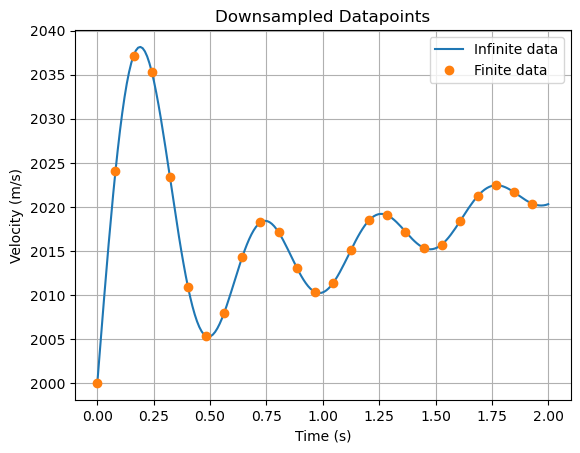

In [14]:
fig, ax = plt.subplots(1, 1)

ax.plot(time, vrms, label="Infinite data")
ax.plot(time_obs, vrms_obs, "o", label="Finite data")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")
ax.set_title("Downsampled Datapoints")
ax.grid()
ax.legend()

fig.savefig("Q3A.png", dpi=300, bbox_inches="tight")

In [15]:
spline_interp = interp1d(time_obs, vrms_obs, kind="cubic", fill_value="extrapolate")
linear_interp = interp1d(time_obs, vrms_obs, kind="linear", fill_value="extrapolate")

In [16]:
vrms_interp_spline = spline_interp(time)
vrms_interp_linear = linear_interp(time)

vint_interp_spline = compute_vint_from_vrms(time, vrms_interp_spline)
vint_interp_linear = compute_vint_from_vrms(time, vrms_interp_linear)

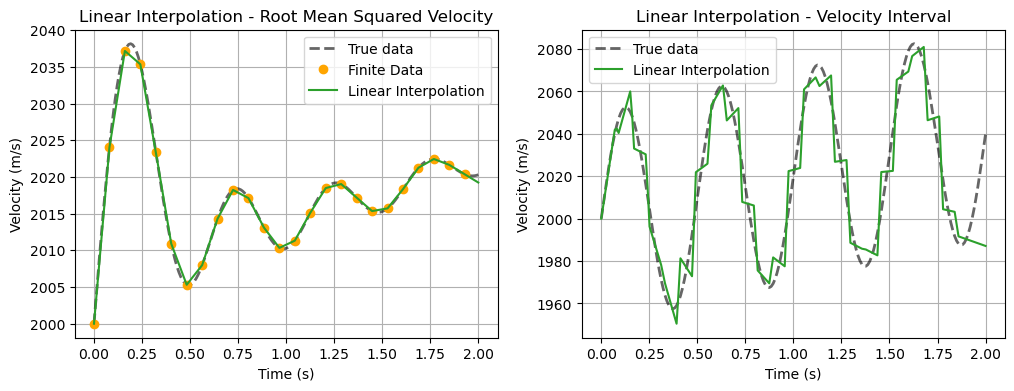

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(time, vrms, label="True data", c="k", lw=2, ls="--", alpha=0.6)
ax[0].plot(time_obs, vrms_obs, "o", c="orange", alpha=1, label="Finite Data")
ax[0].plot(time, vrms_interp_linear, color="C2", label="Linear Interpolation") 
ax[0].set_title("Linear Interpolation - Root Mean Squared Velocity")
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Velocity (m/s)")

ax[1].plot(time, vint, label="True data", c="k", lw=2, ls="--", alpha=0.6)
ax[1].plot(time, vint_interp_linear, color="C2", label="Linear Interpolation") 
ax[1].set_title("Linear Interpolation - Velocity Interval")
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Velocity (m/s)")

fig.savefig("Q3B.png", dpi=300, bbox_inches="tight")

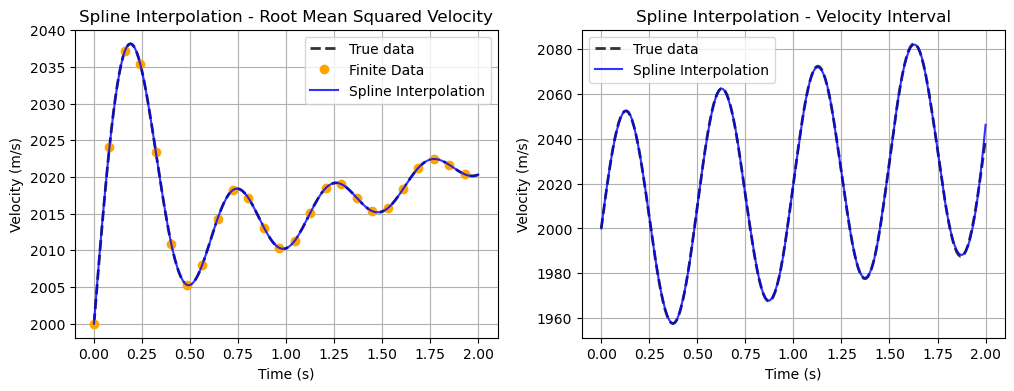

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(time, vrms, label="True data", c="k", lw=2, ls="--", alpha=0.8)
ax[0].plot(time_obs, vrms_obs, "o", c="orange", alpha=1, label="Finite Data")
ax[0].plot(time, vrms_interp_spline, color="b", alpha=0.8, label="Spline Interpolation") 
ax[0].set_title("Spline Interpolation - Root Mean Squared Velocity")
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Velocity (m/s)")

ax[1].plot(time, vint, label="True data", c="k", lw=2, ls="--", alpha=0.8)
ax[1].plot(time, vint_interp_spline, color="b", alpha=0.8, label="Spline Interpolation") 
ax[1].set_title("Spline Interpolation - Velocity Interval")
ax[1].legend()
ax[1].grid()
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Velocity (m/s)")

fig.savefig("Q3C.png", dpi=300, bbox_inches="tight")

###  Multiple Decimation Levels

In [43]:
dec_factors = [4, 16, 32]

time_dec = {}
vrms_dec = {}
spline_dec_interp = {}
linear_dec_interp = {}
vrms_dec_interp_spline = {}
vrms_dec_interp_linear = {}
vint_dec_rec_spline = {}
vint_dec_rec_linear = {}

for i in dec_factors:
    time_dec[i] = time[::i]
    vrms_dec[i] = vrms[::i]
    spline_dec_interp[i] = interp1d(time_dec[i], vrms_dec[i], kind="cubic", fill_value="extrapolate")
    linear_dec_interp[i] = interp1d(time_dec[i], vrms_dec[i], kind="linear", fill_value="extrapolate")
    vrms_dec_interp_spline[i] = spline_dec_interp[i](time)
    vrms_dec_interp_linear[i] = linear_dec_interp[i](time)
    vint_dec_rec_spline[i] = compute_vint_from_vrms(time, vrms_dec_interp_spline[i])
    vint_dec_rec_linear[i] = compute_vint_from_vrms(time, vrms_dec_interp_linear[i])

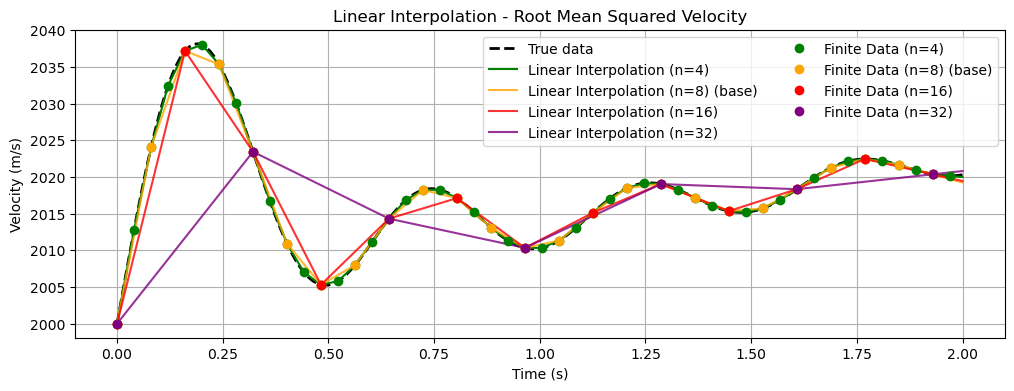

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vrms, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time, vrms_dec_interp_linear[4], c="green", alpha=1, label="Linear Interpolation (n=4)")
ax.plot(time, vrms_interp_linear, c="orange", alpha=0.8, label="Linear Interpolation (n=8) (base)")
ax.plot(time, vrms_dec_interp_linear[16], c="red", alpha=0.8, label="Linear Interpolation (n=16)")
ax.plot(time, vrms_dec_interp_linear[32], c="purple", alpha=0.8, label="Linear Interpolation (n=32)")
ax.plot(time_dec[4], vrms_dec[4], "o", c="green", alpha=1, label="Finite Data (n=4)")
ax.plot(time_obs, vrms_obs, "o", c="orange", alpha=1, label="Finite Data (n=8) (base)")
ax.plot(time_dec[16], vrms_dec[16], "o", c="red", alpha=1, label="Finite Data (n=16)")
ax.plot(time_dec[32], vrms_dec[32], "o", c="purple", alpha=1, label="Finite Data (n=32)")
ax.set_title("Linear Interpolation - Root Mean Squared Velocity")
ax.legend(loc = "upper right",ncol=2)
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q3D_lin1.png", dpi=300, bbox_inches="tight")

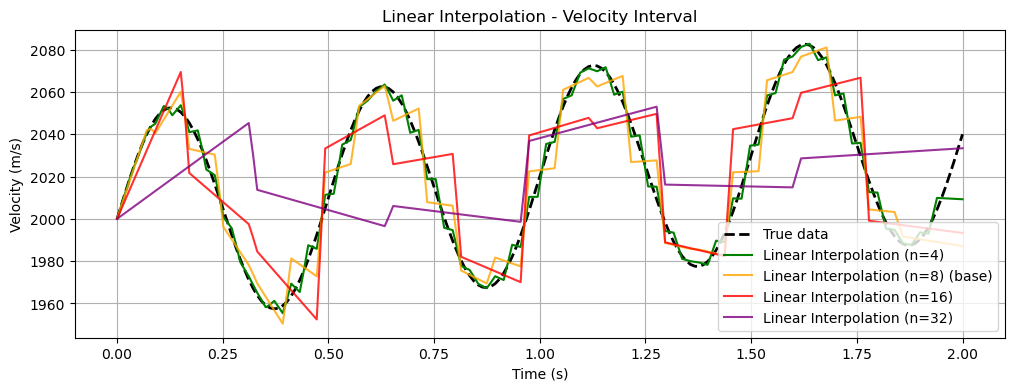

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vint, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time, vint_dec_rec_linear[4], c="green", alpha=1, label="Linear Interpolation (n=4)")
ax.plot(time, vint_interp_linear, c="orange", alpha=0.8, label="Linear Interpolation (n=8) (base)")
ax.plot(time, vint_dec_rec_linear[16], c="red", alpha=0.8, label="Linear Interpolation (n=16)")
ax.plot(time, vint_dec_rec_linear[32], c="purple", alpha=0.8, label="Linear Interpolation (n=32)")
ax.set_title("Linear Interpolation - Velocity Interval")
ax.legend(loc = "lower right")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q3D_lin2.png", dpi=300, bbox_inches="tight")

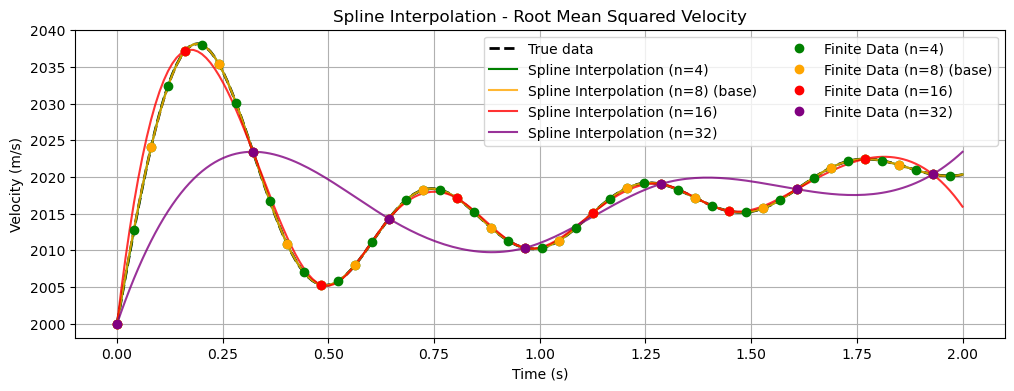

In [96]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vrms, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time, vrms_dec_interp_spline[4], c="green", alpha=1, label="Spline Interpolation (n=4)")
ax.plot(time, vrms_interp_spline, c="orange", alpha=0.8, label="Spline Interpolation (n=8) (base)")
ax.plot(time, vrms_dec_interp_spline[16], c="red", alpha=0.8, label="Spline Interpolation (n=16)")
ax.plot(time, vrms_dec_interp_spline[32], c="purple", alpha=0.8, label="Spline Interpolation (n=32)")
ax.plot(time_dec[4], vrms_dec[4], "o", c="green", alpha=1, label="Finite Data (n=4)")
ax.plot(time_obs, vrms_obs, "o", c="orange", alpha=1, label="Finite Data (n=8) (base)")
ax.plot(time_dec[16], vrms_dec[16], "o", c="red", alpha=1, label="Finite Data (n=16)")
ax.plot(time_dec[32], vrms_dec[32], "o", c="purple", alpha=1, label="Finite Data (n=32)")
ax.set_title("Spline Interpolation - Root Mean Squared Velocity")
ax.legend(loc = "upper right",ncol=2)
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q3D_spline1.png", dpi=300, bbox_inches="tight")

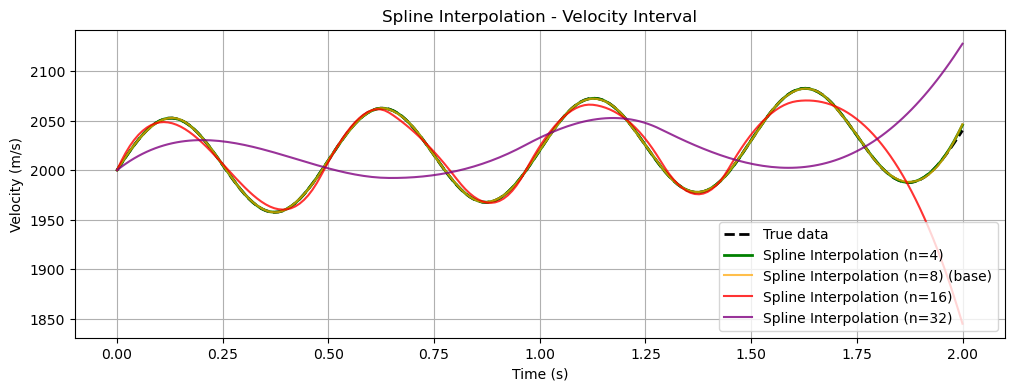

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vint, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time, vint_dec_rec_spline[4], c="green", lw=2, alpha=1, label="Spline Interpolation (n=4)")
ax.plot(time, vint_interp_spline, c="orange", alpha=0.7, label="Spline Interpolation (n=8) (base)")
ax.plot(time, vint_dec_rec_spline[16], c="red", alpha=0.8, label="Spline Interpolation (n=16)")
ax.plot(time, vint_dec_rec_spline[32], c="purple", alpha=0.8, label="Spline Interpolation (n=32)")
ax.set_title("Spline Interpolation - Velocity Interval")
ax.legend(loc = "lower right")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q3D_spline2.png", dpi=300, bbox_inches="tight")

## With Noise

In [108]:
noise_levels = [0.5, 1, 2]
decimate_noise = 8

time_noise = {}
vrms_noise = {}
spline_noise_interp = {}
linear_noise_interp = {}
vrms_noise_interp_spline = {}
vrms_noise_interp_linear = {}
vint_noise_rec_spline = {}
vint_noise_rec_linear = {}


for i in noise_levels:
    time_noise[i] = time[::decimate_noise]
    #NOISE: careful with what random function is used - need to understand whether the random is skewed (i.e., positive skew via np.random)
    vrms_noise[i] = vrms[::decimate_noise] + np.random.normal(loc=0, scale=i, size=len(time_obs))
    spline_noise_interp[i] = interp1d(time_noise[i], vrms_noise[i], kind="cubic", fill_value="extrapolate")
    linear_noise_interp[i] = interp1d(time_noise[i], vrms_noise[i], kind="linear", fill_value="extrapolate")
    vrms_noise_interp_spline[i] = spline_noise_interp[i](time)
    vrms_noise_interp_linear[i] = linear_noise_interp[i](time)
    vint_noise_rec_spline[i] = compute_vint_from_vrms(time, vrms_noise_interp_spline[i])
    vint_noise_rec_linear[i] = compute_vint_from_vrms(time, vrms_noise_interp_linear[i])

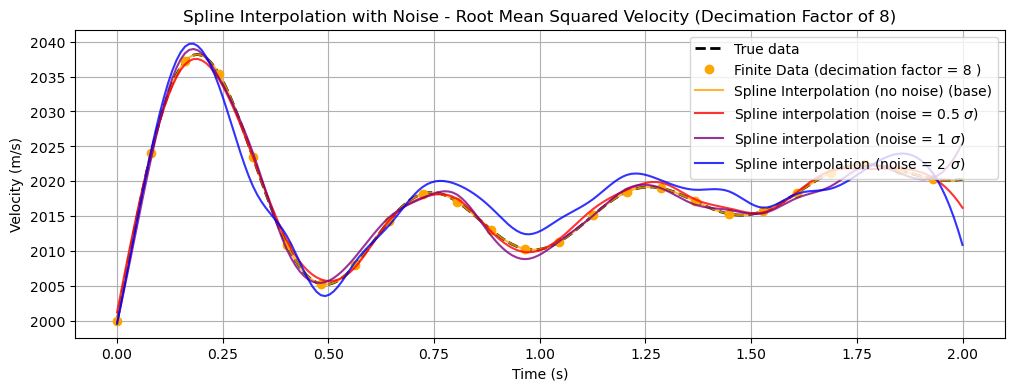

In [112]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vrms, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time_obs, vrms_obs, "o", c="orange", alpha=1, label="Finite Data (decimation factor = 8 )")
ax.plot(time, vrms_interp_spline, c="orange", alpha=0.8, label="Spline Interpolation (no noise) (base)")
ax.plot(time, vrms_noise_interp_spline[0.5], c="red", alpha=0.8, label=r"Spline interpolation (noise = 0.5 $\sigma$)")
ax.plot(time, vrms_noise_interp_spline[1], c="purple", alpha=0.8, label=r"Spline interpolation (noise = 1 $\sigma$)")
ax.plot(time, vrms_noise_interp_spline[2], c="blue", alpha=0.8, label=r"Spline interpolation (noise = 2 $\sigma$)")
ax.set_title("Spline Interpolation with Noise - Root Mean Squared Velocity (Decimation Factor of 8)")
ax.legend(loc = "upper right")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q4a_vrms.png", dpi=300, bbox_inches="tight")

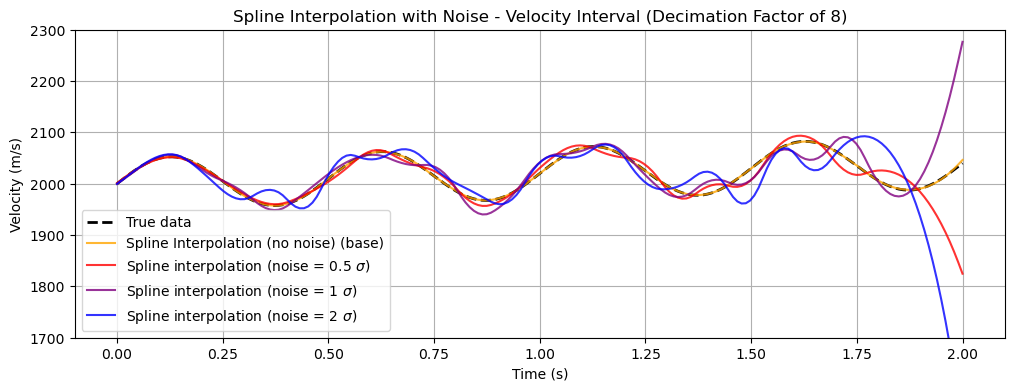

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vint, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time, vint_interp_spline, c="orange", alpha=0.8, label="Spline Interpolation (no noise) (base)")
ax.plot(time, vint_noise_rec_spline[0.5], c="red", alpha=0.8, label=r"Spline interpolation (noise = 0.5 $\sigma$)")
ax.plot(time, vint_noise_rec_spline[1], c="purple", alpha=0.8, label=r"Spline interpolation (noise = 1 $\sigma$)")
ax.plot(time, vint_noise_rec_spline[2], c="blue", alpha=0.8, label=r"Spline interpolation (noise = 2 $\sigma$)")
ax.set_title("Spline Interpolation with Noise - Velocity Interval (Decimation Factor of 8)")
ax.legend(loc = "lower left")
ax.set_ylim(1700,2300)
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q4a_vint.png", dpi=300, bbox_inches="tight")

## Correlated Noise, Alpha = 0

In [135]:
vrmsA0 = rms_velocity(init_velocity, 0, b, omega, time)
vintA0 = interval_velocity_func(init_velocity, 0, b, omega, time)

In [129]:
noise_corr = [0, 0.5, 1, 2]
decimate_corr = 8

time_corr = {}
vrms_corr = {}
spline_corrnoise_interp = {}
linear_corrnoise_interp = {}
vrms_corrnoise_interp_spline = {}
vrms_corrnoise_interp_linear = {}
vint_corrnoise_rec_spline = {}
vint_corrnoise_rec_linear = {}                     

for i in noise_corr:
    time_corr[i] = time[::decimate_corr]
    #uniform random distribution over 0 to 2pi (no preference in that range (i.e., not centered around any value, like 0))
    phi = np.random.uniform(0, 2*np.pi)
    noise_corr_val = i * np.cos(omega*time_corr[i] + phi)
    vrms_corr[i] = vrmsA0[::decimate_corr] + noise_corr_val
    spline_corrnoise_interp[i] = interp1d(time_corr[i], vrms_corr[i], kind="cubic", fill_value="extrapolate")
    linear_corrnoise_interp[i] = interp1d(time_corr[i], vrms_corr[i], kind="linear", fill_value="extrapolate")
    vrms_corrnoise_interp_spline[i] = spline_corrnoise_interp[i](time)
    vrms_corrnoise_interp_linear[i] = linear_corrnoise_interp[i](time)
    vint_corrnoise_rec_spline[i] = compute_vint_from_vrms(time, vrms_corrnoise_interp_spline[i])
    vint_corrnoise_rec_linear[i] = compute_vint_from_vrms(time, vrms_corrnoise_interp_linear[i])

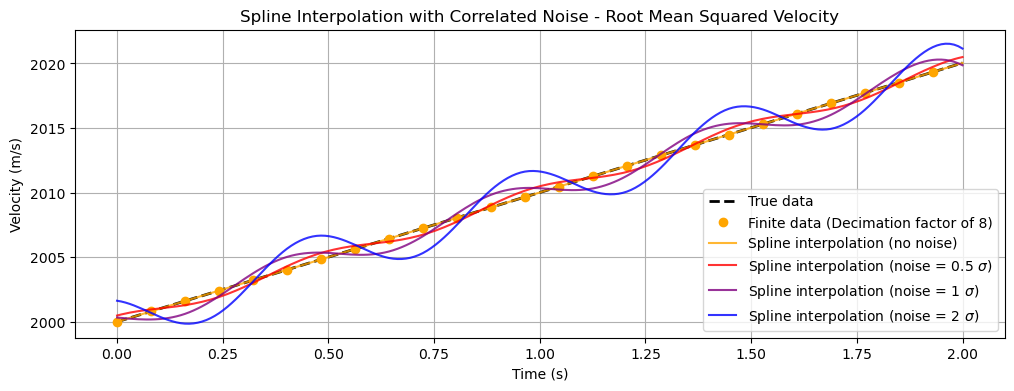

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vrmsA0, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time_corr[0], vrms_corr[0], "o", c="orange", alpha=1, label="Finite data (Decimation factor of 8)")
ax.plot(time, vrms_corrnoise_interp_spline[0], c="orange", alpha=0.8, label=r"Spline interpolation (no noise)")
ax.plot(time, vrms_corrnoise_interp_spline[0.5], c="red", alpha=0.8, label=r"Spline interpolation (noise = 0.5 $\sigma$)")
ax.plot(time, vrms_corrnoise_interp_spline[1], c="purple", alpha=0.8, label=r"Spline interpolation (noise = 1 $\sigma$)")
ax.plot(time, vrms_corrnoise_interp_spline[2], c="blue", alpha=0.8, label=r"Spline interpolation (noise = 2 $\sigma$)")
ax.set_title("Spline Interpolation with Correlated Noise - Root Mean Squared Velocity")
ax.legend(loc = "lower right")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q4B_vrms.png", dpi=300, bbox_inches="tight")

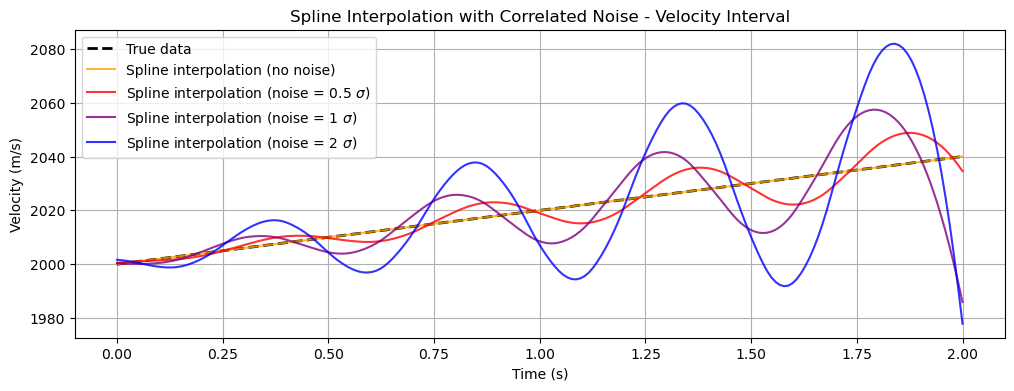

In [139]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ax.plot(time, vintA0, label="True data", c="k", lw=2, ls="--", alpha=1)
ax.plot(time, vint_corrnoise_rec_spline[0], c="orange", alpha=0.8, label=r"Spline interpolation (no noise)")
ax.plot(time, vint_corrnoise_rec_spline[0.5], c="red", alpha=0.8, label=r"Spline interpolation (noise = 0.5 $\sigma$)")
ax.plot(time, vint_corrnoise_rec_spline[1], c="purple", alpha=0.8, label=r"Spline interpolation (noise = 1 $\sigma$)")
ax.plot(time, vint_corrnoise_rec_spline[2], c="blue", alpha=0.8, label=r"Spline interpolation (noise = 2 $\sigma$)")
ax.set_title("Spline Interpolation with Correlated Noise - Velocity Interval")
ax.legend(loc = "upper left")
ax.grid()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Velocity (m/s)")

fig.savefig("Q4b_vint.png", dpi=300, bbox_inches="tight")